# Modul 3: Optimizer dan Strategi Pelatihan

**Nama:** Luthfia Laila Ramadhani
**NIM:** 123450004
**Kelas:** Deep Learning RB 
**Tanggal:** 2026-09-29

Simpan berkas ini sebagai `M03_NIM.ipynb` sebelum mulai mengerjakan.

## Petunjuk

Notebook ini memiliki tiga jenis bagian. Tanda di akhir judul menunjukkan jenisnya.

| Tanda | Bagian | Yang Anda lakukan |
|:---|:---|:---|
| **Terbimbing** | Pre-lab, B–F | Jawaban lengkap Prosedur Praktikum Terbimbing sudah tersedia, termasuk run tanpa scheduler, `StepLR`, batch 32, dan batch 512 pada bagian F. Jalankan, baca kodenya, lalu cocokkan keluarannya dengan tab **Materi** modul. |
| **Latihan Mandiri di Lab** | Latihan | Dikerjakan sendiri di laboratorium setelah bagian terbimbing. |
| **Tugas Individu** | F (lanjutan), G | Run `CosineAnnealingLR` dan batch 128, `metrics.csv` lengkap, serta pertanyaan analisis. Dikerjakan di luar sesi dan dikumpulkan lewat Tugas. |

1. Isi identitas di atas dan `NIM` pada sel pertama. Hanya itu isian pada bagian terbimbing.
2. Siapkan Fashion-MNIST lewat tombol **Siapkan dataset di laptop** di halaman modul. Setelah itu tekan **Restart**, lalu **Run all**. Seluruh sel terbimbing berjalan di kernel Deep Learning (PyTorch CPU) dan berhenti di sel Latihan pertama yang masih berisi `TODO`.
3. Keluaran yang tidak bergantung pada NIM, misalnya jumlah parameter model, harus sama persis dengan naskah. Split, loss, dan akurasi bergantung pada seed NIM Anda, sedangkan runtime bergantung pada perangkat.
4. Protokol tetap: subset 12.000/3.000, model 784 → 128 → 10, batch 128, dan 5 epoch. Pada bagian Latihan dan Tugas, ganti seluruh penanda `TODO`, ubah **hanya** faktor yang sedang diuji, dan panggil fungsi `jalankan()` yang sama untuk setiap run.
5. Pilih model dari validation loss. Data uji sudah dipakai **satu kali** pada bagian E dan tidak dipakai lagi.
6. Catat setiap run ke `metrics.csv`, termasuk run yang gagal. Sebelum mengumpulkan, jalankan **Restart** lalu **Run all** sampai seluruh sel selesai tanpa galat.

In [3]:
import math
import platform
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import FashionMNIST

# Kernel Workbench menangkap figure di akhir setiap sel; plt.show() dipertahankan
# agar notebook tetap berjalan di Jupyter biasa, tanpa peringatan backend Agg.
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive')

NIM = '123450004'  # Ganti dengan NIM lengkap Anda, misalnya '120140167'.
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
SEED = int(NIM[-4:])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.12.5', 'numpy': '2.5.3', 'pandas': '3.0.5', 'torch': '2.14.0+cpu', 'device': 'cpu', 'seed': 4}

## A. Pre-lab · Terbimbing

Contoh jawaban. Bandingkan dengan jawaban Anda sendiri sebelum sesi.

1. **Jumlah update satu epoch bila $n=12\,000$ dan batch $=128$:** $\lceil12000/128\rceil=94$ update (93 batch penuh dan satu batch terakhir berisi 96 contoh). Lima epoch berarti 470 update.
2. **Derau gradien pada mini-batch:** Gradien sebuah mini-batch hanya merupakan estimasi gradien seluruh dataset; komposisi sampel yang berubah membuat arah dan besarnya berfluktuasi. Full-batch memakai semua contoh pada setiap update, sehingga tidak memiliki variasi akibat pemilihan subset—walaupun optimisasi tetap dapat sulit karena bentuk permukaan loss.
3. **Mengapa learning rate yang sama belum tentu adil:** SGD, Momentum, dan Adam mengubah gradien menjadi langkah dengan aturan dan skala efektif berbeda. Aturan yang berbeda membuat learning rate yang sama menghasilkan besar langkah efektif yang tidak setara, sehingga setiap optimizer perlu dituning pada rentangnya sendiri.
4. **Perkiraan kurva bila learning rate dinaikkan sepuluh kali:** Loss mungkin turun lebih cepat pada awalnya, tetapi jika langkah melewati minimum kurva menjadi bergerigi/berosilasi, dapat naik, atau menjadi non-finite. Kapan gejala itu mulai tampak perlu dibaca dari kurva run Anda sendiri.

## B. Data dan protokol · Terbimbing

Ambil subset terstratifikasi dan hitung statistik normalisasi **hanya** dari subset latih.

In [5]:
DATA_ROOT = Path('../../data/raw')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('data/raw')

latih_penuh = FashionMNIST(root=DATA_ROOT, train=True, download=False,
                           transform=transforms.ToTensor())
uji_resmi = FashionMNIST(root=DATA_ROOT, train=False, download=False,
                         transform=transforms.ToTensor())

X_penuh = latih_penuh.data.float().unsqueeze(1) / 255.0
y_penuh = latih_penuh.targets
X_uji = uji_resmi.data.float().unsqueeze(1) / 255.0
y_uji = uji_resmi.targets

semua_indeks = np.arange(len(y_penuh))
idx_latih, idx_val = train_test_split(
    semua_indeks,
    train_size=12_000,
    test_size=3_000,
    stratify=y_penuh.numpy(),
    random_state=SEED,
)

X_latih, y_latih = X_penuh[idx_latih], y_penuh[idx_latih]
X_val, y_val = X_penuh[idx_val], y_penuh[idx_val]

MEAN = X_latih.mean()
STD = X_latih.std()
if not torch.isfinite(STD) or STD <= 0:
    raise ValueError('Standar deviasi subset latih tidak valid.')

def normalkan(tensor):
    return (tensor - MEAN) / STD

ds_latih = TensorDataset(normalkan(X_latih), y_latih)
ds_val = TensorDataset(normalkan(X_val), y_val)
ds_uji = TensorDataset(normalkan(X_uji), y_uji)

print(f'latih {len(ds_latih)}  validasi {len(ds_val)}  uji {len(ds_uji)}')
print(f'mean={MEAN.item():.6f}  std={STD.item():.6f}')
print('distribusi kelas latih:', torch.bincount(y_latih).tolist())

# Pemeriksaan wajib.
assert (len(ds_latih), len(ds_val), len(ds_uji)) == (12_000, 3_000, 10_000)
assert torch.bincount(y_latih).min().item() == 1_200, 'subset harus terstratifikasi'
print('split sesuai protokol')

latih 12000  validasi 3000  uji 10000
mean=0.286465  std=0.353340
distribusi kelas latih: [1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200, 1200]
split sesuai protokol


In [6]:
BATCH = 128
EPOCH = 5

def buat_model():
    seed_everything(SEED)
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    ).to(DEVICE)

def buat_optimizer(nama, params, lr):
    nama = nama.strip().lower()
    if nama == 'sgd':
        return torch.optim.SGD(params, lr=lr)
    if nama == 'momentum':
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if nama == 'adam':
        return torch.optim.Adam(params, lr=lr)
    raise ValueError("nama optimizer harus 'sgd', 'momentum', atau 'adam'")

def loader(ds, batch, acak):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=batch, shuffle=acak,
                      generator=generator if acak else None)

@torch.no_grad()
def evaluasi(model, ds, batch=512):
    model.eval()
    kriteria = nn.CrossEntropyLoss(reduction='sum')
    total_loss, benar = 0.0, 0
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += kriteria(logits, yb).item()
        benar += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(ds), benar / len(ds)

jumlah_parameter = sum(parameter.numel() for parameter in buat_model().parameters())
print('jumlah parameter:', jumlah_parameter)
assert jumlah_parameter == 101_770, 'arsitektur belum sesuai protokol'

jumlah parameter: 101770


In [7]:
def jalankan(nama_opt, lr, batch=BATCH, epoch=EPOCH, scheduler=None):
    model = buat_model()
    optimizer = buat_optimizer(nama_opt, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss()
    scheduler_name = 'none' if scheduler is None else str(scheduler).lower()
    if scheduler_name == 'none':
        lr_scheduler = None
    elif scheduler_name == 'step':
        lr_scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=2, gamma=0.5,
        )
    elif scheduler_name == 'cosine':
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epoch,
        )
    else:
        raise ValueError("scheduler harus None, 'step', atau 'cosine'")

    train_loader = loader(ds_latih, batch, True)
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'val_acc': [], 'learning_rate': [],
    }
    gradient_norms = []
    updates = 0
    status = 'ok'
    start = time.perf_counter()

    for epoch_index in range(1, epoch + 1):
        model.train()
        loss_sum = 0.0
        examples_seen = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            if not torch.isfinite(loss):
                status = f'failed_nonfinite_epoch_{epoch_index}'
                break
            loss.backward()
            squared_norm = sum(
                parameter.grad.detach().norm(2).item() ** 2
                for parameter in model.parameters()
                if parameter.grad is not None
            )
            gradient_norms.append(math.sqrt(squared_norm))
            optimizer.step()
            updates += 1
            loss_sum += loss.item() * len(xb)
            examples_seen += len(xb)

        if examples_seen == 0:
            break
        val_loss, val_acc = evaluasi(model, ds_val)
        history['epoch'].append(epoch_index)
        history['train_loss'].append(loss_sum / examples_seen)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        if lr_scheduler is not None:
            lr_scheduler.step()
        if status != 'ok':
            break

    runtime = time.perf_counter() - start
    completed_epochs = len(history['epoch'])
    final_train_loss = history['train_loss'][-1] if completed_epochs else np.nan
    final_val_loss = history['val_loss'][-1] if completed_epochs else np.nan
    final_val_acc = history['val_acc'][-1] if completed_epochs else np.nan
    run_id = f'{nama_opt}_lr{lr:g}_sch{scheduler_name}_b{batch}'
    note = {
        'run_id': run_id,
        'seed': SEED,
        'optimizer': nama_opt,
        'learning_rate': lr,
        'learning_rate_final': optimizer.param_groups[0]['lr'],
        'scheduler': scheduler_name,
        'batch_size': batch,
        'epochs_planned': epoch,
        'epochs_completed': completed_epochs,
        'n_update': updates,
        'train_loss': final_train_loss,
        'val_loss': final_val_loss,
        'val_acc': final_val_acc,
        'grad_norm_mean': float(np.mean(gradient_norms)) if gradient_norms else np.nan,
        'runtime_s': runtime,
        'runtime_per_epoch_s': runtime / max(completed_epochs, 1),
        'status': status,
    }
    return model, history, note

## C. Baseline dan tiga learning rate · Terbimbing

Jalankan SGD pada $\eta \in \{0{,}001;\;0{,}1;\;1{,}0\}$, tampilkan ketiga kurva dalam satu grafik, lalu cocokkan dengan tabel gejala pada modul.

In [5]:
learning_rates_baseline = [0.001, 0.1, 1.0]
hasil_lr = []
riwayat_lr = {}

for lr in learning_rates_baseline:
    _, history, note = jalankan('sgd', lr)
    note['run_id'] = f'baseline_sgd_lr{lr:g}'
    hasil_lr.append(note)
    riwayat_lr[note['run_id']] = history
    print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
          f"val_acc={note['val_acc']:.4f}, grad_norm={note['grad_norm_mean']:.4f}")

df_lr_baseline = pd.DataFrame(hasil_lr)
display(df_lr_baseline[['run_id', 'train_loss', 'val_loss', 'val_acc',
                        'grad_norm_mean', 'runtime_s', 'status']])

fig, ax = plt.subplots(figsize=(8, 5))
for run_id, history in riwayat_lr.items():
    ax.plot(history['epoch'], history['val_loss'], marker='o', label=run_id)
ax.set(title='Validation Loss SGD pada Tiga Learning Rate',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

baseline_sgd_lr0.001: val_loss=1.3956, val_acc=0.6680, grad_norm=1.7210


In [6]:
baseline_by_lr = df_lr_baseline.set_index('learning_rate')
small = baseline_by_lr.loc[0.001]
medium = baseline_by_lr.loc[0.1]
large = baseline_by_lr.loc[1.0]

reading = fr"""
**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **{small['val_loss']:.4f}**, accuracy **{small['val_acc']:.4f}**, dan `grad_norm_mean` **{small['grad_norm_mean']:.4f}**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **{medium['val_loss']:.4f}**, accuracy **{medium['val_acc']:.4f}**, dan `grad_norm_mean` **{medium['grad_norm_mean']:.4f}**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **{large['val_loss']:.4f}**, accuracy **{large['val_acc']:.4f}**, dan `grad_norm_mean` **{large['grad_norm_mean']:.4f}**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.
"""
display(Markdown(reading))



**Pembacaan kurva:**

- $\eta=0.001$: turun lambat; validation loss akhir **1.3956**, accuracy **0.6680**, dan `grad_norm_mean` **1.7210**. Learning rate terlalu kecil untuk anggaran lima epoch.
- $\eta=0.1$: turun lebih cepat dan relatif stabil; validation loss akhir **0.4499**, accuracy **0.8303**, dan `grad_norm_mean` **1.3691**.
- $\eta=1.0$: langkah sangat agresif; validation loss akhir **1.9480**, accuracy **0.2750**, dan `grad_norm_mean` **1.2915**. Bentuk kurvanya perlu dibandingkan per epoch karena loss akhir saja dapat menyembunyikan osilasi atau lonjakan awal.


## D. Sembilan run terkendali · Terbimbing

Setiap optimizer diuji pada tiga learning rate-nya sendiri. Model diinisialisasi ulang dari seed yang sama sebelum setiap run.

In [7]:
grid = {
    'sgd': [0.01, 0.1, 0.5],
    'momentum': [0.01, 0.05, 0.1],
    'adam': [1e-4, 1e-3, 1e-2],
}

hasil, riwayat_semua = [], {}
for optimizer_name, learning_rates in grid.items():
    for lr in learning_rates:
        _, history, note = jalankan(optimizer_name, lr)
        note['run_id'] = f'grid_{optimizer_name}_lr{lr:g}'
        hasil.append(note)
        riwayat_semua[note['run_id']] = history
        print(f"{note['run_id']}: val_loss={note['val_loss']:.4f}, "
              f"val_acc={note['val_acc']:.4f}, runtime={note['runtime_s']:.2f}s")

tabel = pd.DataFrame(hasil)
display(tabel[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
               'grad_norm_mean', 'runtime_s', 'status']].sort_values('val_loss'))
assert len(tabel) == 9, 'harus ada sembilan run inti'

grid_sgd_lr0.01: val_loss=0.6101, val_acc=0.7767, runtime=4.95s
grid_sgd_lr0.1: val_loss=0.4499, val_acc=0.8303, runtime=4.73s
grid_sgd_lr0.5: val_loss=0.5388, val_acc=0.8007, runtime=4.87s
grid_momentum_lr0.01: val_loss=0.4317, val_acc=0.8443, runtime=5.12s
grid_momentum_lr0.05: val_loss=0.4153, val_acc=0.8537, runtime=5.08s
grid_momentum_lr0.1: val_loss=0.5419, val_acc=0.8240, runtime=5.45s
grid_adam_lr0.0001: val_loss=0.5427, val_acc=0.8077, runtime=5.76s
grid_adam_lr0.001: val_loss=0.4185, val_acc=0.8447, runtime=6.09s
grid_adam_lr0.01: val_loss=0.4233, val_acc=0.8537, runtime=6.17s


,run_id,optimizer,learning_rate,val_loss,val_acc,grad_norm_mean,runtime_s,status
4,grid_momentum_lr0.05,momentum,0.0500,0.4153,0.8537,1.2162,5.0788,ok
7,grid_adam_lr0.001,adam,0.0010,0.4185,0.8447,1.5826,6.0858,ok
8,grid_adam_lr0.01,adam,0.0100,0.4233,0.8537,1.6789,6.1746,ok
3,grid_momentum_lr0.01,momentum,0.0100,0.4317,0.8443,1.4216,5.1244,ok
1,grid_sgd_lr0.1,sgd,0.1000,0.4499,0.8303,1.3691,4.7335,ok
2,grid_sgd_lr0.5,sgd,0.5000,0.5388,0.8007,1.1950,4.8704,ok
5,grid_momentum_lr0.1,momentum,0.1000,0.5419,0.8240,1.1834,5.4522,ok
6,grid_adam_lr0.0001,adam,0.0001,0.5427,0.8077,1.3320,5.7561,ok
0,grid_sgd_lr0.01,sgd,0.0100,0.6101,0.7767,1.2631,4.9479,ok


## E. Memilih model dan evaluasi akhir · Terbimbing

Pilih learning rate terbaik tiap optimizer dari **validation loss**, bandingkan ketiga pemenang, lalu evaluasi data uji **satu kali** pada satu model final.

Konfigurasi final berdasarkan validation loss: grid_momentum_lr0.05


,run_id,optimizer,learning_rate,val_loss,val_acc,runtime_s,runtime_per_epoch_s
0,grid_momentum_lr0.05,momentum,0.050,0.4153,0.8537,5.0788,1.0158
1,grid_adam_lr0.001,adam,0.001,0.4185,0.8447,6.0858,1.2172
2,grid_sgd_lr0.1,sgd,0.100,0.4499,0.8303,4.7335,0.9467


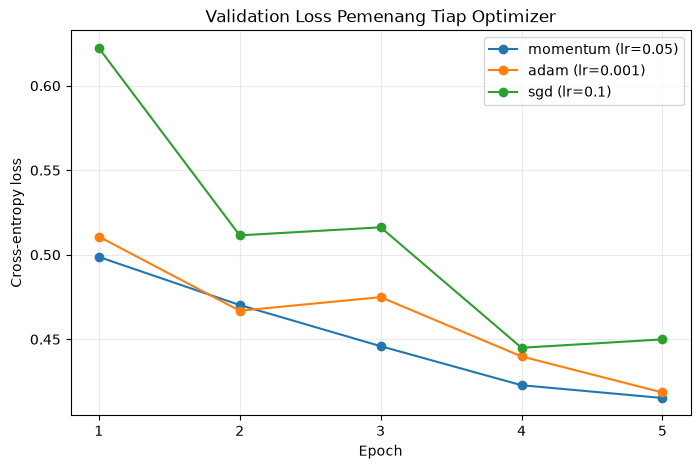

In [8]:
eligible = tabel[(tabel['status'] == 'ok') & np.isfinite(tabel['val_loss'])].copy()
pemenang = (
    eligible.sort_values('val_loss')
    .groupby('optimizer', as_index=False, sort=False)
    .first()
    .sort_values('val_loss')
    .reset_index(drop=True)
)
assert set(pemenang['optimizer']) == set(grid)
display(pemenang[['run_id', 'optimizer', 'learning_rate', 'val_loss', 'val_acc',
                   'runtime_s', 'runtime_per_epoch_s']])

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in pemenang.iterrows():
    history = riwayat_semua[row['run_id']]
    ax.plot(history['epoch'], history['val_loss'], marker='o',
            label=f"{row['optimizer']} (lr={row['learning_rate']:g})")
ax.set(title='Validation Loss Pemenang Tiap Optimizer',
       xlabel='Epoch', ylabel='Cross-entropy loss')
ax.set_xticks(range(1, EPOCH + 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

best_overall = pemenang.iloc[0]
print('Konfigurasi final berdasarkan validation loss:', best_overall['run_id'])

,run_id,selection_val_loss,test_loss,test_acc,most_confused_pair,pair_errors
0,final_retrain_momentum_lr0.05,0.4153,0.445,0.8452,T-shirt/top ↔ Shirt,274


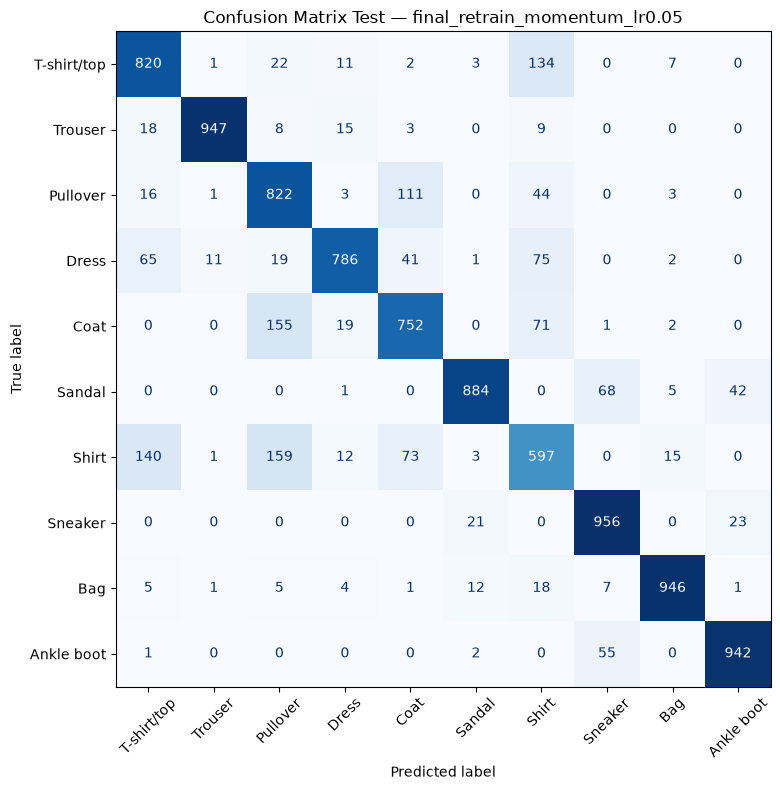

In [9]:
model_final, riwayat_final, catatan_final = jalankan(
    best_overall['optimizer'],
    float(best_overall['learning_rate']),
    batch=BATCH,
    epoch=EPOCH,
    scheduler=None,
)
catatan_final['run_id'] = f"final_retrain_{best_overall['optimizer']}_lr{best_overall['learning_rate']:g}"

@torch.no_grad()
def evaluasi_uji_sekali(model, ds, batch=512):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss = 0.0
    labels_all, predictions_all = [], []
    for xb, yb in loader(ds, batch, False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item()
        labels_all.append(yb.cpu())
        predictions_all.append(logits.argmax(1).cpu())
    labels = torch.cat(labels_all).numpy()
    predictions = torch.cat(predictions_all).numpy()
    return total_loss / len(ds), float((predictions == labels).mean()), labels, predictions

# Satu-satunya iterasi atas ds_uji dalam notebook.
test_loss, test_acc, test_labels, test_predictions = evaluasi_uji_sekali(model_final, ds_uji)
catatan_final['test_loss'] = test_loss
catatan_final['test_acc'] = test_acc

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]
cm = confusion_matrix(test_labels, test_predictions)
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d', xticks_rotation=45,
)
ax.set_title(f"Confusion Matrix Test — {catatan_final['run_id']}")
plt.tight_layout()
plt.show()

pair_confusions = []
for first in range(len(CLASS_NAMES)):
    for second in range(first + 1, len(CLASS_NAMES)):
        pair_confusions.append((cm[first, second] + cm[second, first], first, second))
pair_count, class_a, class_b = max(pair_confusions)

final_summary = pd.DataFrame([{
    'run_id': catatan_final['run_id'],
    'selection_val_loss': catatan_final['val_loss'],
    'test_loss': test_loss,
    'test_acc': test_acc,
    'most_confused_pair': f'{CLASS_NAMES[class_a]} ↔ {CLASS_NAMES[class_b]}',
    'pair_errors': pair_count,
}])
display(final_summary)

**Checkpoint menit ke-95.** Tunjukkan tabel sembilan run dan grafik tiga pemenang kepada asisten sebelum melanjutkan ke bagian F.

## F. Scheduler dan batch size · Terbimbing

Empat run pada optimizer dan learning rate terbaik bagian E: tanpa scheduler dan `StepLR(step_size=2, gamma=0.5)` pada batch 128, lalu batch 32 dan 512 tanpa scheduler. Anggaran tetap lima epoch.

learning rate per epoch dengan StepLR: [0.05, 0.05, 0.025, 0.025, 0.0125]


,run_id,scheduler,batch_size,n_update,val_loss,val_acc,runtime_s,runtime_per_epoch_s,status
0,scheduler_none_momentum_lr0.05,none,128,470,0.4153,0.8537,6.1033,1.2207,ok
1,scheduler_step_momentum_lr0.05,step,128,470,0.4003,0.8547,6.0884,1.2177,ok
2,batch_32_momentum_lr0.05,none,32,1875,0.7160,0.7953,13.7663,2.7533,ok
3,batch_512_momentum_lr0.05,none,512,120,0.4773,0.8217,3.9842,0.7968,ok


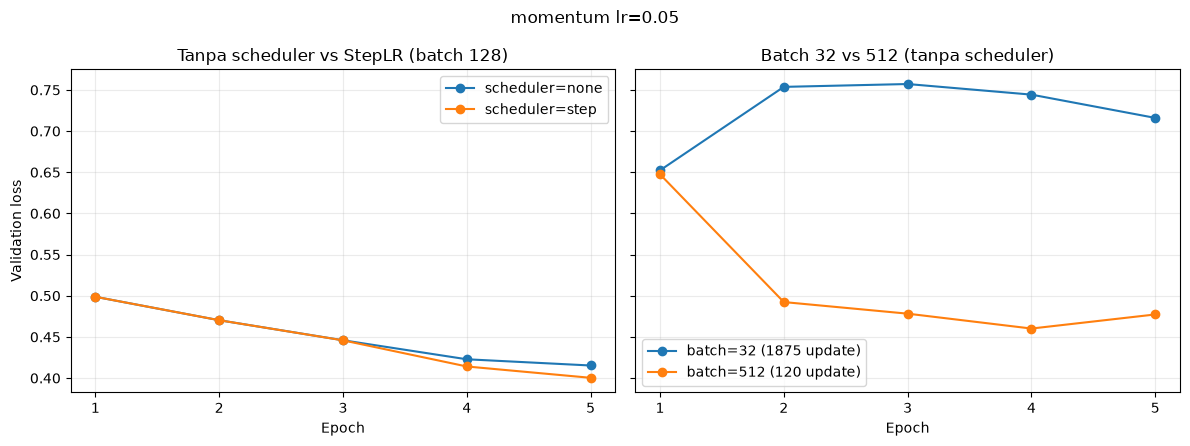

In [10]:
tambahan_terbimbing = []
riwayat_tambahan = {}
best_optimizer = str(best_overall['optimizer'])
best_lr = float(best_overall['learning_rate'])

# Tanpa scheduler vs StepLR pada anggaran epoch yang sama.
for scheduler_name in (None, 'step'):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=BATCH, epoch=EPOCH,
        scheduler=scheduler_name,
    )
    label = 'none' if scheduler_name is None else scheduler_name
    note['run_id'] = f'scheduler_{label}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'scheduler'
    tambahan_terbimbing.append(note)
    riwayat_tambahan[note['run_id']] = history

# Batch 32 dan 512 tanpa scheduler.
for batch_size in (32, 512):
    _, history, note = jalankan(
        best_optimizer, best_lr, batch=batch_size, epoch=EPOCH, scheduler=None,
    )
    note['run_id'] = f'batch_{batch_size}_{best_optimizer}_lr{best_lr:g}'
    note['experiment_group'] = 'batch_size'
    tambahan_terbimbing.append(note)
    riwayat_tambahan[note['run_id']] = history

df_bagian_f = pd.DataFrame(tambahan_terbimbing)
display(df_bagian_f[['run_id', 'scheduler', 'batch_size', 'n_update',
                     'val_loss', 'val_acc', 'runtime_s', 'runtime_per_epoch_s', 'status']])
print('learning rate per epoch dengan StepLR:',
      riwayat_tambahan[f'scheduler_step_{best_optimizer}_lr{best_lr:g}']['learning_rate'])
assert len(df_bagian_f) == 4
assert (df_bagian_f['status'] == 'ok').all()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, group, title in zip(axes, ['scheduler', 'batch_size'],
                            ['Tanpa scheduler vs StepLR (batch 128)', 'Batch 32 vs 512 (tanpa scheduler)']):
    for note in tambahan_terbimbing:
        if note['experiment_group'] != group:
            continue
        history = riwayat_tambahan[note['run_id']]
        label = (f"scheduler={note['scheduler']}" if group == 'scheduler'
                 else f"batch={note['batch_size']} ({note['n_update']} update)")
        ax.plot(history['epoch'], history['val_loss'], marker='o', label=label)
    ax.set(title=title, xlabel='Epoch')
    ax.set_xticks(range(1, EPOCH + 1))
    ax.grid(alpha=0.25)
    ax.legend()
axes[0].set_ylabel('Validation loss')
fig.suptitle(f'{best_optimizer} lr={best_lr:g}')
plt.tight_layout()
plt.show()

## Latihan Mandiri di Lab

Berdasarkan hasil Bagian E, jelaskan mengapa batch 32 menghasilkan 1.875 update sedangkan batch 512 hanya 120 update untuk anggaran epoch yang sama. Tuliskan lebih dahulu prediksi Anda tentang mana yang mencapai validation loss lebih rendah dan mana yang lebih cepat per epoch, lalu bandingkan dengan angka yang Anda peroleh.

Tuliskan prediksi, hasil, dan perbandingannya di `latihan-03.md`, lalu kumpulkan lewat tugas **Latihan Mandiri di Lab — Modul 03**.

Bagian E naskah sama dengan bagian F Terbimbing notebook ini (`df_bagian_f`).

**Prediksi:** Saya memprediksi bahwa batch size 32 akan menghasilkan validation loss yang lebih rendah dibandingkan batch size 512 karena pembaruan parameter dilakukan lebih sering dalam setiap epoch. Namun, batch size 512 diprediksi memiliki waktu pelatihan per epoch yang lebih cepat karena jumlah update yang dilakukan jauh lebih sedikit.

In [11]:
# Jumlah update per epoch dan total untuk batch 32 dan 512, dihitung dari len(ds_latih) dan EPOCH,
# lalu dicocokkan dengan kolom n_update pada df_bagian_f (bagian F).

n_latih = len(ds_latih)
baris_latihan = []
for b in (32, 512):
    update_per_epoch = math.ceil(n_latih / b)
    update_total = update_per_epoch * EPOCH
    batch_terakhir = n_latih - (update_per_epoch - 1) * b
    run = df_bagian_f[df_bagian_f['batch_size'] == b].iloc[0]
    assert update_total == int(run['n_update']), f'n_update batch {b} tidak cocok dengan hitungan'
    baris_latihan.append({
        'batch': b,
        'update_per_epoch': update_per_epoch,
        'ukuran_batch_terakhir': batch_terakhir,
        'update_total_hitung': update_total,
        'n_update_tabel': int(run['n_update']),
        'val_loss': run['val_loss'],
        'val_acc': run['val_acc'],
        'runtime_per_epoch_s': run['runtime_per_epoch_s'],
    })
df_latihan = pd.DataFrame(baris_latihan).set_index('batch')
display(df_latihan)

# Bandingkan val_loss dan runtime_per_epoch_s kedua run dengan prediksi.
b32, b512 = df_latihan.loc[32], df_latihan.loc[512]
val_lebih_rendah = 32 if b32['val_loss'] < b512['val_loss'] else 512
lebih_cepat = 32 if b32['runtime_per_epoch_s'] < b512['runtime_per_epoch_s'] else 512
prediksi_val_benar = (val_lebih_rendah == 32)
prediksi_cepat_benar = (lebih_cepat == 512)
print('validation loss lebih rendah :', f'batch {val_lebih_rendah}', '| prediksi benar:', prediksi_val_benar)
print('lebih cepat per epoch        :', f'batch {lebih_cepat}', '| prediksi benar:', prediksi_cepat_benar)

validation loss lebih rendah : batch 512 | prediksi benar: False
lebih cepat per epoch        : batch 512 | prediksi benar: True


,update_per_epoch,ukuran_batch_terakhir,update_total_hitung,n_update_tabel,val_loss,val_acc,runtime_per_epoch_s
batch,,,,,,,
32,375,32,1875,1875,0.7160,0.7953,2.7533
512,24,224,120,120,0.4773,0.8217,0.7968


### Hasil dan perbandingan dengan prediksi

**Jawaban:** Update per epoch itu rumusnya 12.000/batch. Batch 32 menghasilkan 375 per epoch, mendapatkan total update sebanyak 1.875. Sedangkan Batch 512 menghasilkan 24 per epoch (23 batch penuh + 1 sisa 224 contoh), mendapatkan total update sebanyak 120. Keduanya cocok dengan kolom n_update.

Prediksi kecepatan benar, Batch 512 lebih cepat (0,73 s vs 2,30 s per epoch) karena update nya jauh lebih sedikit. Namun, prediksi loss salah saya awalnya saya mengira batch 32 lebih rendah, tapi ternyata batch 512 justru lebih baik (val_loss 0,4773 vs 0,7160). Dugaan saya, gradien batch kecil lebih berderau sehingga hasil akhirnya memantul, dan 120 update batch 512 sudah cukup. Ini masih dugaan dari satu seed.

### Hipotesis awal · Tugas Individu

Tuliskan hipotesis yang Anda buat sebelum sesi: optimizer mana yang Anda perkirakan menang, dan atas dasar apa? Bandingkan dengan hasil bagian D dan E.

**Jawaban:** Sebelum sesi saya menduga Adam yang menang. Adam menyesuaikan besar langkah tiap parameter memakai estimasi momen gradien, jadi Adam tidak terlalu bergantung pada skala gradien dan biasanya turun cepat di beberapa epoch awal, yang kebetulan itulah seluruh anggaran kita. Momentum ditaruh di urutan kedua karena mengumpulkan arah gradien yang konsisten dan meredam gerak zig-zag. SGD polos ditaruh di akhir karena langkahnya paling kasar dan paling sensitif pada learning rate. Perbandingannya dengan bagian D dan E ada di keluaran sel di bawah.

## F. Scheduler dan batch size - 15 poin · Tugas Individu

Enam run tambahan, seluruhnya memakai optimizer dan learning rate terbaik Anda. Empat di antaranya (tanpa scheduler, `StepLR`, batch 32, dan batch 512) sudah tersedia dari bagian F Terbimbing di `tambahan_terbimbing`; lengkapi run `CosineAnnealingLR` dan batch 128.

In [12]:
# TODO 10: lengkapi dua run yang belum tersedia

tambahan = list(tambahan_terbimbing)

# Tambahkan run CosineAnnealingLR
_, history, note = jalankan(
    best_optimizer,
    best_lr,
    batch=BATCH,
    epoch=EPOCH,
    scheduler='cosine',
)
note['run_id'] = f'scheduler_cosine_{best_optimizer}_lr{best_lr:g}'
note['experiment_group'] = 'scheduler'
tambahan.append(note)

# Tambahkan run batch size 128
_, history, note = jalankan(
    best_optimizer,
    best_lr,
    batch=128,
    epoch=EPOCH,
    scheduler=None,
)
note['run_id'] = f'batch_128_{best_optimizer}_lr{best_lr:g}'
note['experiment_group'] = 'batch_size'
tambahan.append(note)

df_tambahan = pd.DataFrame(tambahan)

print(df_tambahan[['run_id', 'scheduler', 'batch_size', 'n_update',
                   'val_loss', 'val_acc', 'runtime_s']].to_string(index=False))

assert len(df_tambahan) == 6, 'harus ada enam run tambahan'

                          run_id scheduler  batch_size  n_update  val_loss  val_acc  runtime_s
  scheduler_none_momentum_lr0.05      none         128       470    0.4153   0.8537     6.1033
  scheduler_step_momentum_lr0.05      step         128       470    0.4003   0.8547     6.0884
        batch_32_momentum_lr0.05      none          32      1875    0.7160   0.7953    13.7663
       batch_512_momentum_lr0.05      none         512       120    0.4773   0.8217     3.9842
scheduler_cosine_momentum_lr0.05    cosine         128       470    0.3884   0.8583     6.2988
       batch_128_momentum_lr0.05      none         128       470    0.4153   0.8537     6.0287


In [13]:
# Gabungkan seluruh run (baseline learning rate, sembilan run inti, retrain final,
# dan enam run tambahan) ke satu metrics.csv. Run yang gagal ikut tercatat.

df_final_log = pd.DataFrame([catatan_final])
semua = pd.concat([df_lr_baseline, tabel, df_final_log, df_tambahan], ignore_index=True)
semua.insert(0, 'module', 'M03')
semua.insert(1, 'student_id', NIM)
assert semua['run_id'].is_unique, 'run_id harus unik'
semua.to_csv(f'M03_{NIM}_metrics.csv', index=False)
print(f'{len(semua)} baris tersimpan ke M03_{NIM}_metrics.csv')
print(semua['status'].value_counts().to_string())
assert len(semua) >= 15, 'metrics.csv minimal berisi 15 run'

19 baris tersimpan ke M03_123450004_metrics.csv
status
ok    19


## G. Pertanyaan analisis - bagian dari 15 poin · Tugas Individu

1. Apakah optimizer dengan validation loss terendah juga yang tercepat? Tidak. Val_loss terendah dicapai Momentum (0,4153), tapi yang tercepat SGD: 0,95 s per epoch, Momentum 1,02 s, Adam 1,22 s (pada run pemenang masing-masing). Selisih SGD-Momentum sangat kecil. Waktu run yang sama juga berubah dari 5,08 s ke sekitar 6,1 s di bagian F, jadi pengukuran waktunya berderau sekitar 20%. Adam paling lambat karena menyimpan dan memperbarui dua buffer per parameter.

2. Mengapa learning rate terbaik Adam jauh lebih kecil daripada SGD? Learning rate terbaik Adam 0,001, SGD 0,1, jadi SGD sekitar 100 kali lebih besar. Pada SGD, langkah = learning rate × gradien. Norma gradien rata-rata run SGD terbaik 1,37 yang tersebar di 101.770 parameter, jadi gradien per parameter hanya sekitar 0,004 (1,37/√101.770) dan langkahnya sekitar 0,0004. Adam membagi gradien dengan akar rata-rata kuadratnya sehingga langkah tiap parameter kira-kira sebesar learning rate itu sendiri, berapa pun skala gradiennya. Jadi Adam cukup dengan lr=0,001 untuk langkah yang setara. Lr=0,0001 sudah terlalu kecil (val_loss 0,5427).

3. Apa yang terjadi saat learning rate terlalu besar, dan pada epoch keberapa gejalanya terlihat? Langkah melewati dasar lembah sehingga loss memantul dan tidak turun. SGD lr=1,0 paling jelas: val_loss sudah sekitar 1,9 di epoch 1 (lr=0,1 hanya sekitar 0,62), naik ke sekitar 2,1 di epoch 2, sempat turun ke sekitar 1,8 di epoch 4, lalu naik lagi di epoch 5 (akhir 1,9480, akurasi 0,2750). Gejalanya sudah terlihat sejak epoch 1 dan kenaikannya di epoch 2 dan 5. Pada grid, lr yang terlalu besar juga memperburuk hasil: SGD 0,5 (0,5388 vs 0,4499 pada lr=0,1) dan Momentum 0,1 (0,5419 vs 0,4153 pada lr=0,05).

4. Apakah scheduler memperbaiki hasil pada anggaran epoch yang sama? Bila tidak, mengapa? Ya, sedikit. Val_loss akhir: tanpa scheduler 0,4153, StepLR 0,4003, Cosine 0,3884 (akurasi 0,8537, 0,8547, 0,8583). Kurvanya identik sampai epoch 3, lalu StepLR dan Cosine turun lebih jauh karena learning rate diperkecil (StepLR: 0,05, 0,05, 0,025, 0,025, 0,0125) sehingga derau mini-batch di akhir teredam. Selisihnya kecil (0,015 dan 0,027) dan hanya dari satu seed, jadi belum pasti.

5. Batch size mana yang Anda rekomendasikan bila anggaran diukur dalam **waktu**, bukan epoch? Batch 128. Waktu total lima epoch: batch 32 = 13,8 s, batch 128 = 6,1 s, batch 512 = 4,0 s. Dengan budget sekitar 4 s, batch 128 selesai sekitar 3 epoch dengan val_loss sekitar 0,446, sudah lebih baik daripada batch 512 yang selesai lima epoch di 0,4773. Batch 32 paling lambat dan hasilnya paling buruk (0,7160). Batch 512 hanya menang bila waktunya sangat mepet (di bawah sekitar 2 s). Ini berlaku di perangkat saya dan bisa berbeda di perangkat lain.

**Keterbatasan.** Modul ini memakai subset $12\,000$ citra dan $5$ epoch. Sebutkan apa yang tidak boleh disimpulkan dari hasil ini: Dengan 12.000 citra, 5 epoch, dan satu seed, saya tidak menyimpulkan bahwa Momentum pasti terbaik (selisih dengan Adam cuma 0,0032), bahwa learning rate dari grid tiga titik adalah optimum sebenarnya, atau bahwa scheduler dan batch size terbaik di sini berlaku di perangkat, model, atau dataset lain. Akurasi uji juga tidak bisa dipakai membandingkan optimizer karena hanya dipakai sekali pada satu model.

## Checklist sebelum mengumpulkan

- [ ] Identitas, seed, versi library, dan device tercantum.
- [ ] Seluruh `TODO` dan `raise NotImplementedError` sudah diganti.
- [ ] Split, normalisasi, dan jumlah parameter lolos sel pemeriksaan.
- [ ] Seluruh run memanggil `jalankan()` yang sama.
- [ ] `metrics.csv` memuat minimal 15 run, termasuk yang gagal.
- [ ] Pemenang dipilih dari validation loss; data uji dipakai satu kali.
- [ ] Grafik berlabel lengkap dan keterbatasan subset disebutkan.
- [ ] Notebook lolos *Restart Kernel and Run All*.